### Plotting stability metrics across years

- Load lek stability data
- Plot cross-year nearest-neighbour distance
- Plot displacement of the intensity mode

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
## Output folder for figures
out_dir = Path("output")
out_dir.mkdir(exist_ok=True)

In [3]:
## Load stability metrics
stab = pd.read_csv('processed_data/stability_ALL.csv', parse_dates=['date_now', 'date_prev'])

## Factor ordering + labels
lek_order = ['Velavadar_LEK1', 'Velavadar_LEK2', 'TalChhapar_TC']
lek_labels = {'Velavadar_LEK1': 'Velavadar Lek 1','Velavadar_LEK2': 'Velavadar Lek 2','TalChhapar_TC': 'Tal Chhapar'}

stab['lek_id'] = (pd.Categorical(stab['lek_id'],categories=lek_order,ordered=True).rename_categories(lek_labels))

In [4]:
## Colour palettes (matched to R script)
fill_cols = {'Velavadar Lek 1': '#4DAF4A', 'Velavadar Lek 2': '#377EB8', 'Tal Chhapar': '#D6604D'}
point_cols = {'Velavadar Lek 1': '#1B7837', 'Velavadar Lek 2': '#2166AC', 'Tal Chhapar': '#8B1A1A'}

lek_labels = stab['lek_id'].cat.categories.tolist()

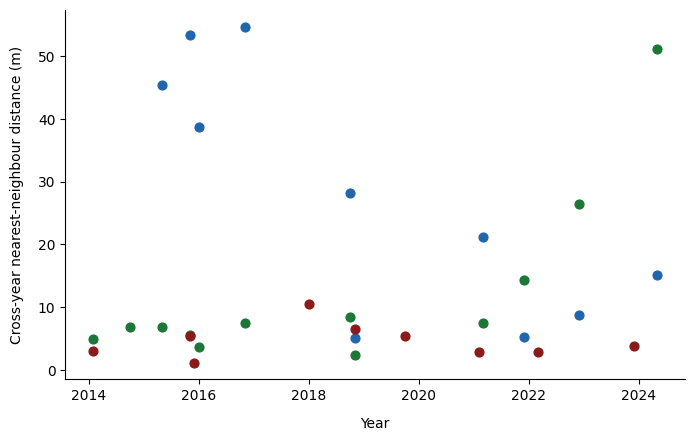

In [12]:
## Time series of cross-year NND

fig, ax = plt.subplots(figsize=(8, 4.8))

for lek in lek_labels:
    sub = stab.loc[stab["lek_id"] == lek]
    ax.scatter(
        sub['date_now'],
        sub['nn_cross_median'],
        s=40,
        color=point_cols[lek],
        label=lek
    )

ax.set_xlabel('Year', labelpad=10)
ax.set_ylabel('Cross-year nearest-neighbour distance (m)', labelpad=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

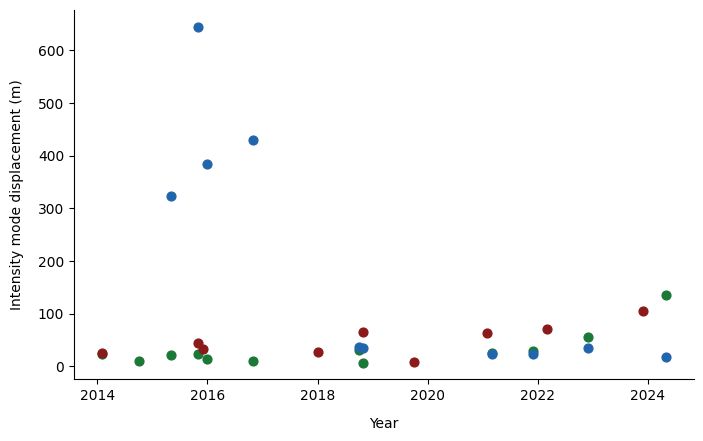

In [13]:
## Time series of mode displacement

fig, ax = plt.subplots(figsize=(8, 4.8))

for lek in lek_labels:
    sub = stab.loc[stab['lek_id'] == lek]
    ax.scatter(
        sub['date_now'],
        sub['mode_shift'],
        s=40,
        color=point_cols[lek],
        label=lek
    )

ax.set_xlabel('Year', labelpad=10)
ax.set_ylabel('Intensity mode displacement (m)', labelpad=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)